# 썸네일 피처 분석: ~34세 vs 65세+
**대상**: `시사/뉴스/사건` subcategory  
**비교**: 주 시청자층이 ~34세인 영상 vs 65세+ 인 영상

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from scipy import stats

# 한글 폰트
def set_korean_font():
    candidates = [
        "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
        "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    ]
    for f in candidates:
        if Path(f).exists():
            fm.fontManager.addfont(f)
            plt.rcParams["font.family"] = fm.FontProperties(fname=f).get_name()
            return
    plt.rcParams["font.family"] = "DejaVu Sans"

set_korean_font()
plt.rcParams["axes.unicode_minus"] = False
pd.set_option('display.float_format', '{:.4f}'.format)

## 1. 데이터 로드

In [2]:
DATA_DIR = Path("../../Data/SOCIETY")
MERGED_CSV = DATA_DIR / "SOCIETY_new_category_v3_add_thumnail_title_features_merged.csv"
OUTPUT_DIR = Path("outputs")

TARGET_SUBCATEGORY = "시사/뉴스/사건"

df_all = pd.read_csv(MERGED_CSV, low_memory=False)
df = df_all[df_all["subcategory"] == TARGET_SUBCATEGORY].copy().reset_index(drop=True)

print(f"전체 행 수: {len(df_all):,}")
print(f"'{TARGET_SUBCATEGORY}' 필터 후: {len(df):,}")
print(f"컬럼 수: {len(df.columns)}")
df.head(3)

전체 행 수: 48,697
'시사/뉴스/사건' 필터 후: 17,247
컬럼 수: 25


,video_id,subcategory,age_~17,age_18~24,age_25~34,age_35~44,age_45~54,age_55~64,age_65~,person_ratio,...,color_warm_ratio,color_entropy,color_hue_std,head_pose,head_pose_face_count,expression_dominant,expression_happy,expression_angry,expression_neutral,expression_sad
0,C7c1tjPipnc,시사/뉴스/사건,0.6358,5.2601,22.3699,21.9075,22.1387,19.6532,8.0347,0.0959,...,0.6201,3.4201,38.6400,없음,0.0000,NaN,NaN,NaN,NaN,NaN
1,RDUrzF86x9c,시사/뉴스/사건,3.7569,19.0055,35.6906,20.5525,13.3702,5.1934,2.4309,0.0351,...,0.4599,3.1032,46.7600,측면,1.0000,NaN,NaN,NaN,NaN,NaN
2,iIbVndDBGnQ,시사/뉴스/사건,3.7569,19.0055,35.6906,20.5525,13.3702,5.1934,2.4309,0.1636,...,0.4893,2.6178,48.2100,정면,2.0000,NaN,NaN,NaN,NaN,NaN


## 2. 연령 그룹 할당

In [3]:
AGE_COLS = ["age_~17", "age_18~24", "age_25~34", "age_35~44", "age_45~54", "age_55~64", "age_65~"]
YOUNG_COLS = ["age_~17", "age_18~24", "age_25~34"]

def assign_group(row):
    dominant = row[AGE_COLS].idxmax()
    if dominant in YOUNG_COLS:
        return "~34세"
    elif dominant == "age_65~":
        return "65세+"
    return None  # 35~64세가 dominant → 분석 제외

df["age_group"] = df.apply(assign_group, axis=1)

cnt = df["age_group"].value_counts()
total = len(df)
print(f"~34세 : {cnt.get('~34세', 0):,}개 ({cnt.get('~34세', 0)/total*100:.2f}%)")
print(f"65세+ : {cnt.get('65세+', 0):,}개 ({cnt.get('65세+', 0)/total*100:.2f}%)")
print(f"제외(중간): {df['age_group'].isna().sum():,}개")

sub = df[df["age_group"].isin(["~34세", "65세+"])].copy()

~34세 : 2,795개 (16.21%)
65세+ : 3,082개 (17.87%)
제외(중간): 11,370개


## 3. 연속형 피처 비교

In [4]:
CONTINUOUS_FEATURES = [
    ("person_ratio",     "인물 비중"),
    ("text_ratio",       "텍스트 비중"),       # feat02 완료 후 활성화
    ("color_saturation", "색상 채도"),
    ("color_brightness", "색상 밝기"),
    ("color_warm_ratio", "따뜻한 색 비율"),
    ("color_entropy",    "색상 다양성(엔트로피)"),
    ("color_hue_std",    "색조 표준편차"),
]

avail = [(f, l) for f, l in CONTINUOUS_FEATURES if f in sub.columns and sub[f].notna().sum() > 10]
print(f"분석 가능한 연속형 피처: {[l for _, l in avail]}")

분석 가능한 연속형 피처: ['인물 비중', '색상 채도', '색상 밝기', '따뜻한 색 비율', '색상 다양성(엔트로피)', '색조 표준편차']


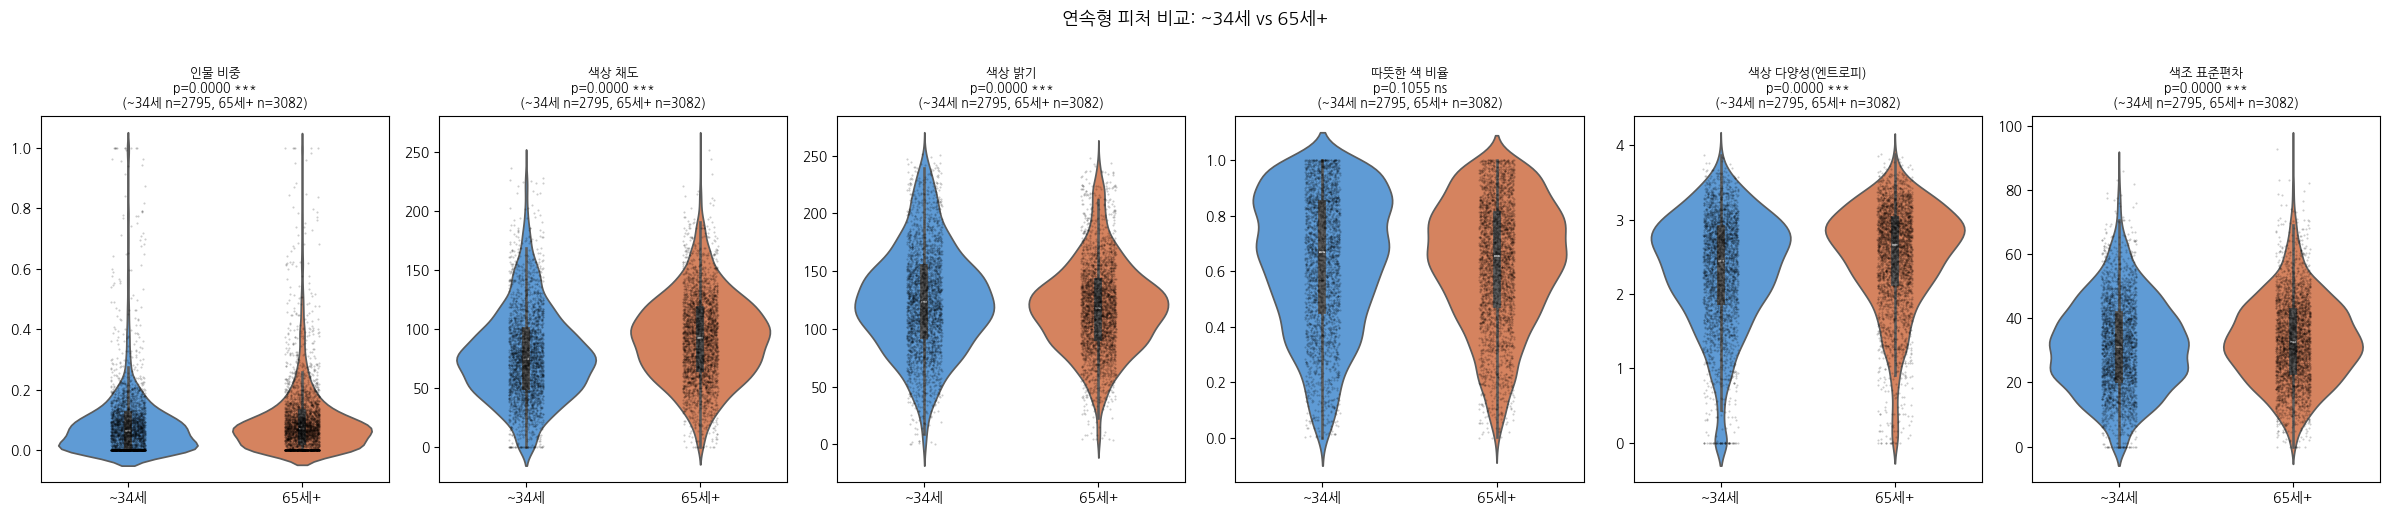

,피처,~34세 평균,65세+ 평균,p값,유의성
0,인물 비중,0.0899,0.0993,0.0000,***
1,색상 채도,77.7747,92.4351,0.0000,***
2,색상 밝기,124.5848,118.4455,0.0000,***
3,따뜻한 색 비율,0.6344,0.6305,0.1055,ns
4,색상 다양성(엔트로피),2.3270,2.5151,0.0000,***
5,색조 표준편차,31.4599,33.0257,0.0000,***


In [5]:
results_cont = []
fig, axes = plt.subplots(1, len(avail), figsize=(4 * len(avail), 5))
if len(avail) == 1:
    axes = [axes]
fig.suptitle("연속형 피처 비교: ~34세 vs 65세+", fontsize=13, y=1.02)

for ax, (feat, label) in zip(axes, avail):
    g0 = sub[sub["age_group"] == "~34세"][feat].dropna()
    g1 = sub[sub["age_group"] == "65세+"][feat].dropna()

    stat, p = stats.mannwhitneyu(g0, g1, alternative="two-sided")
    sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))

    plot_df = pd.concat([
        pd.DataFrame({"값": g0, "그룹": "~34세"}),
        pd.DataFrame({"값": g1, "그룹": "65세+"}),
    ])
    sns.violinplot(data=plot_df, x="그룹", y="값", hue="그룹", ax=ax,
                   palette=["#4C9BE8", "#E87B4C"], legend=False)
    sns.stripplot(data=plot_df, x="그룹", y="값", ax=ax, size=1.5, alpha=0.2, color="black")

    ax.set_title(f"{label}\np={p:.4f} {sig}\n(~34세 n={len(g0)}, 65세+ n={len(g1)})", fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("")

    results_cont.append({
        "피처": label, "~34세 평균": round(g0.mean(), 4), "65세+ 평균": round(g1.mean(), 4),
        "p값": round(p, 6), "유의성": sig
    })

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_continuous_features.png", dpi=150, bbox_inches="tight")
plt.show()

pd.DataFrame(results_cont)

## 4. 범주형 피처 비교

In [6]:
CATEGORICAL_FEATURES = [
    ("person_count_cat",    "인물 수"),
    ("head_pose",           "인물 시선(헤드포즈)"),
    ("expression_dominant", "인물 표정"),       # feat06 완료 후 활성화
]

avail_cat = [(f, l) for f, l in CATEGORICAL_FEATURES if f in sub.columns and sub[f].notna().sum() > 10]
print(f"분석 가능한 범주형 피처: {[l for _, l in avail_cat]}")

분석 가능한 범주형 피처: ['인물 수', '인물 시선(헤드포즈)']


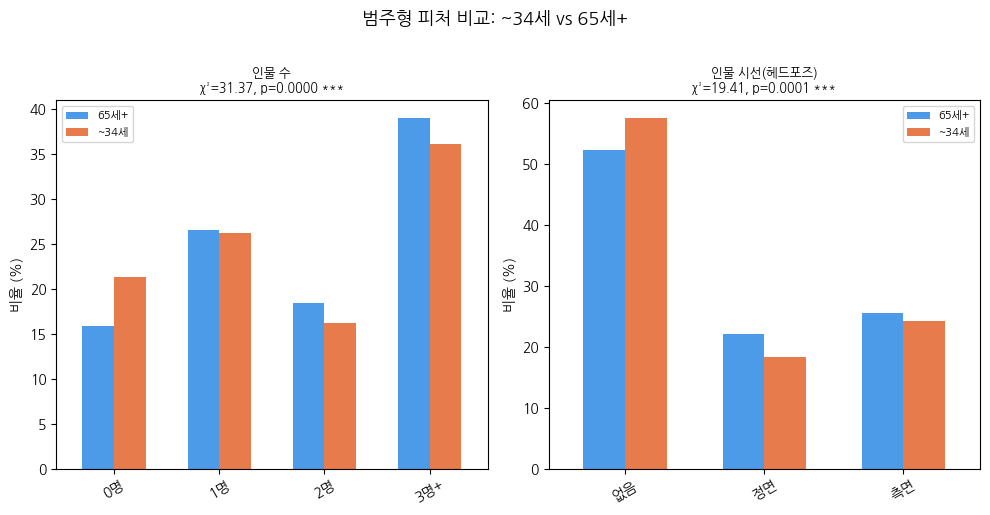

,피처,χ²,p값,자유도,유의성
0,인물 수,31.3690,0.0000,3,***
1,인물 시선(헤드포즈),19.4090,0.0001,2,***


In [7]:
results_cat = []
fig, axes = plt.subplots(1, len(avail_cat), figsize=(5 * len(avail_cat), 5))
if len(avail_cat) == 1:
    axes = [axes]
fig.suptitle("범주형 피처 비교: ~34세 vs 65세+", fontsize=13, y=1.02)

for ax, (feat, label) in zip(axes, avail_cat):
    plot_sub = sub[["age_group", feat]].dropna()
    ct_pct = pd.crosstab(plot_sub[feat], plot_sub["age_group"], normalize="columns") * 100
    ct_raw = pd.crosstab(plot_sub[feat], plot_sub["age_group"])

    ct_pct.plot(kind="bar", stacked=False, ax=ax,
                color=["#4C9BE8", "#E87B4C"], width=0.6)

    chi2, p, dof, _ = stats.chi2_contingency(ct_raw)
    sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))

    ax.set_title(f"{label}\nχ²={chi2:.2f}, p={p:.4f} {sig}", fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("비율 (%)")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(fontsize=8)

    results_cat.append({
        "피처": label, "χ²": round(chi2, 4), "p값": round(p, 6), "자유도": dof, "유의성": sig
    })

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_categorical_features.png", dpi=150, bbox_inches="tight")
plt.show()

pd.DataFrame(results_cat)

## 5. 인물 수 세부 분포

age_group           65세+    ~34세
person_count_cat                
0명               15.9000 21.4000
1명               26.6100 26.2300
2명               18.4300 16.2400
3명+              39.0700 36.1400


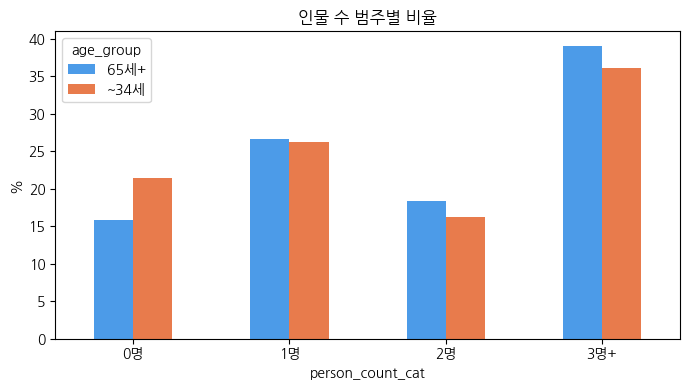

In [8]:
if "person_count_cat" in sub.columns:
    ct = pd.crosstab(sub["person_count_cat"], sub["age_group"], normalize="columns") * 100
    print(ct.round(2))
    ct.plot(kind="bar", figsize=(7, 4), color=["#4C9BE8", "#E87B4C"])
    plt.title("인물 수 범주별 비율")
    plt.ylabel("%")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

## 6. 헤드포즈(시선) 세부 분포

age_group    65세+    ~34세
head_pose                
없음        52.2700 57.5300
정면        22.1300 18.2500
측면        25.6000 24.2200


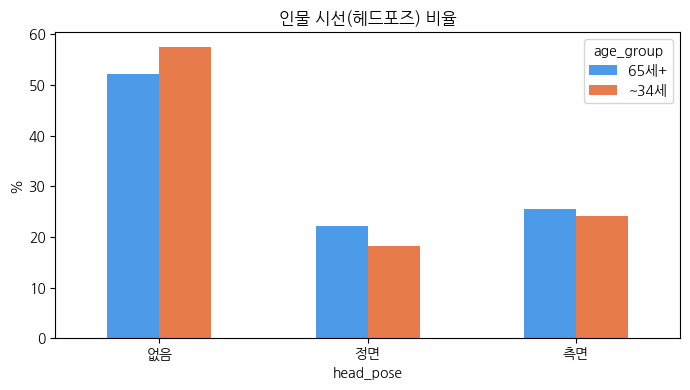

In [9]:
if "head_pose" in sub.columns:
    ct = pd.crosstab(sub["head_pose"], sub["age_group"], normalize="columns") * 100
    print(ct.round(2))
    ct.plot(kind="bar", figsize=(7, 4), color=["#4C9BE8", "#E87B4C"])
    plt.title("인물 시선(헤드포즈) 비율")
    plt.ylabel("%")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

## 7. text_ratio 추가 (feat02 완료 후 실행)
feat02 (`02_text_ratio.py`) 완료 시 아래 셀을 실행하면 merged CSV에 반영됩니다.

In [10]:
# feat02 완료 후 실행
TEXT_CSV = DATA_DIR / "SOCIETY_new_category_v3_add_thumnail_title_text_ratio.csv"

if TEXT_CSV.exists():
    text_df = pd.read_csv(TEXT_CSV, low_memory=False)
    has_data = text_df["text_ratio"].notna().sum() if "text_ratio" in text_df.columns else 0
    print(f"text_ratio 완료 건수: {has_data:,}")

    if has_data > 1000:
        # merged에 병합
        merged = pd.read_csv(MERGED_CSV, low_memory=False)
        text_cols = text_df[["video_id", "text_ratio"]].dropna(subset=["text_ratio"])
        merged = merged.drop(columns=["text_ratio"], errors="ignore")
        merged = merged.merge(text_cols, on="video_id", how="left")
        merged.to_csv(MERGED_CSV, index=False)
        print(f"merged CSV 업데이트 완료 ({merged['text_ratio'].notna().sum():,}건)")
        df = merged  # 전역 df 갱신
else:
    print("text_ratio CSV 없음 또는 아직 진행 중")

text_ratio 완료 건수: 5
